In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf

from sklearn.metrics import classification_report
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.metrics import roc_curve, roc_auc_score
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.metrics import roc_curve, roc_auc_score

import warnings
warnings.filterwarnings("ignore")

In [2]:
data = pd.read_csv("ICU Mortality.csv")
data.rename(columns = {'INF':'INF_C'},inplace = True)
data.head()

,SR NO,ID,STA,AGE,SEX,RACE,SER,CAN,CRN,INF_C,...,HRA,PRE,TYP,FRA,PO2,PH,PCO,BIC,CRE,LOC
0,1,8,0,27,1,1,0,0,0,1,...,88,0,1,0,0,0,0,0,0,0
1,2,12,0,59,0,1,0,0,0,0,...,80,1,1,0,0,0,0,0,0,0
2,3,14,0,77,0,1,1,0,0,0,...,70,0,0,0,0,0,0,0,0,0
3,4,28,0,54,0,1,0,0,0,1,...,103,0,1,1,0,0,0,0,0,0
4,5,32,0,87,1,1,1,0,0,1,...,154,1,1,0,0,0,0,0,0,0


In [4]:
df = data.copy()

In [6]:
df['STA'].replace({0: 'Lived', 1: 'Dead'}, inplace=True)

In [8]:
#To get the count
count = df['STA'].value_counts().reset_index()
#To get percentage count
per = df['STA'].value_counts(normalize = True).reset_index()
df = pd.merge(count,per,on = ['STA'])
df.columns = ['Vital Status','Count','Proportion']
df['Proportion'] = df['Proportion']*100

df

,Vital Status,Count,Proportion
0,Lived,160,80.0
1,Dead,40,20.0


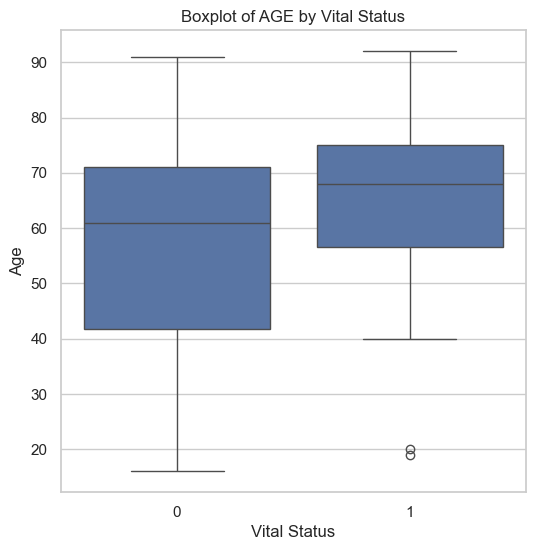

In [9]:
# Set the style for the plot (optional)
sns.set(style="whitegrid")

# Create a boxplot using Seaborn
plt.figure(figsize=(6, 6))
sns.boxplot(x='STA', y='AGE', data=data)
plt.title('Boxplot of AGE by Vital Status')
plt.xlabel('Vital Status')
plt.ylabel('Age')
plt.show()

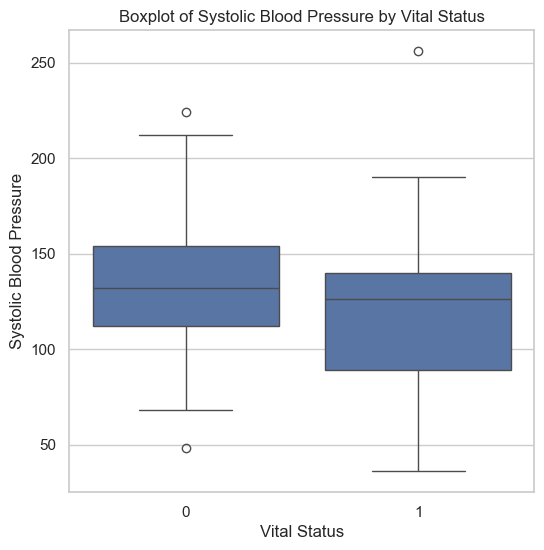

In [10]:
# Set the style for the plot (optional)
sns.set(style="whitegrid")

# Create a boxplot using Seaborn
plt.figure(figsize=(6, 6))
sns.boxplot(x='STA', y='SYS', data=data)
plt.title('Boxplot of Systolic Blood Pressure by Vital Status')
plt.xlabel('Vital Status')
plt.ylabel('Systolic Blood Pressure')
plt.show()

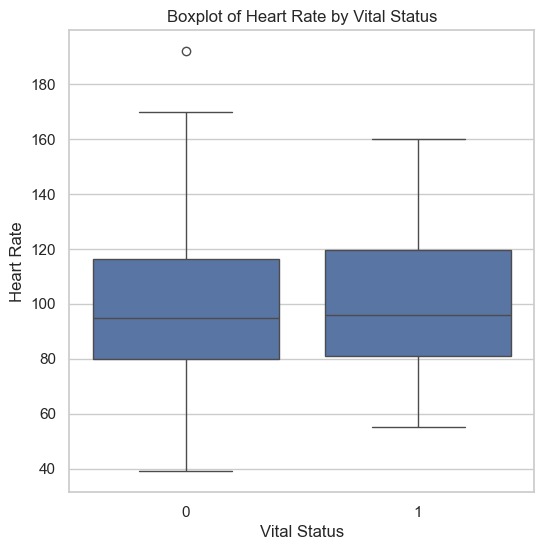

In [11]:
# Set the style for the plot (optional)
sns.set(style="whitegrid")

# Create a boxplot using Seaborn
plt.figure(figsize=(6, 6))
sns.boxplot(x='STA', y='HRA', data=data)
plt.title('Boxplot of Heart Rate by Vital Status')
plt.xlabel('Vital Status')
plt.ylabel('Heart Rate')
plt.show()



In [12]:
# Group the data by SEX and calculate the count of STA for each group
df = data.copy()
df['SEX'].replace({0: 'Male', 1: 'Female'}, inplace=True)

grouped_sex = df.groupby('SEX')['STA'].agg(['count', 'sum']).reset_index()

# Rename the columns for clarity
grouped_sex.columns = ['SEX', 'Total Count', 'Death Count']

# Calculate the death rate as a percentage
grouped_sex['Death Rate(%)'] = (grouped_sex['Death Count'] / grouped_sex['Total Count']) * 100
grouped_sex.round(2)

,SEX,Total Count,Death Count,Death Rate(%)
0,Female,76,16,21.05
1,Male,124,24,19.35


In [13]:
df = data.copy()
df['TYP'].replace({0: 'Elective', 1: 'Emergency'}, inplace=True)

# Group the data by SEX and calculate the count of STA for each group
grouped_typ = df.groupby('TYP')['STA'].agg(['count', 'sum']).reset_index()

# Rename the columns for clarity
grouped_typ.columns = ['TYP', 'Total Count', 'Death Count']

# Calculate the death rate as a percentage
grouped_typ['Death Rate(%)'] = (grouped_typ['Death Count'] / grouped_typ['Total Count']) * 100
grouped_typ.round(2)

,TYP,Total Count,Death Count,Death Rate(%)
0,Elective,53,2,3.77
1,Emergency,147,38,25.85


In [14]:
df = data.copy()
df['LOC'].replace({0: 'No Coma Or Stupor', 1: 'Deep Stupor', 2: 'Coma'}, inplace=True)

# Group the data by SEX and calculate the count of STA for each group
grouped_loc = df.groupby('LOC')['STA'].agg(['count', 'sum']).reset_index()

# Rename the columns for clarity
grouped_loc.columns = ['LOC', 'Total Count', 'Death Count']

# Calculate the death rate as a percentage
grouped_loc['Death Rate(%)'] = (grouped_loc['Death Count'] / grouped_loc['Total Count']) * 100
grouped_loc.round(2)

,LOC,Total Count,Death Count,Death Rate(%)
0,Coma,10,8,80.00
1,Deep Stupor,5,5,100.00
2,No Coma Or Stupor,185,27,14.59


In [15]:
data['LOC']  = np.where(data['LOC']>0,1,0)

In [16]:
# Step 1: Define your formula
formula = 'STA ~ AGE + SEX + SER + CAN + CRN  + INF_C + CPR + SYS + HRA + PRE + TYP + FRA + PO2 + PH + PCO + BIC + CRE + LOC'


In [17]:
# Step 2: Fit the linear regression model
model = smf.logit(formula, data=data).fit()

         Current function value: 0.325995
         Iterations: 35


In [18]:
# Step 3: Print the model summary
print(model.summary())

                           Logit Regression Results                           
Dep. Variable:                    STA   No. Observations:                  200
Model:                          Logit   Df Residuals:                      181
Method:                           MLE   Df Model:                           18
Date:                Thu, 12 Feb 2026   Pseudo R-squ.:                  0.3485
Time:                        18:47:08   Log-Likelihood:                -65.199
converged:                      False   LL-Null:                       -100.08
Covariance Type:            nonrobust   LLR p-value:                 4.957e-08
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -3.7910      1.858     -2.040      0.041      -7.434      -0.148
AGE            0.0437      0.016      2.735      0.006       0.012       0.075
SEX           -0.3125      0.481     -0.649      0.5

In [19]:
# Create a DataFrame to store VIF results
vif_data = pd.DataFrame()
vif_data["Feature"] = model.model.exog_names[1:]  # Exclude intercept
vif_data["VIF"] = [variance_inflation_factor(model.model.exog, i) for i in range(1, model.model.exog.shape[1])]

# Print the VIF DataFrame
print(vif_data)

   Feature       VIF
0      AGE  1.347618
1      SEX  1.096121
2      SER  1.927416
3      CAN  1.375821
4      CRN  1.319146
5    INF_C  1.332957
6      CPR  1.315199
7      SYS  1.171510
8      HRA  1.294332
9      PRE  1.167468
10     TYP  1.892265
11     FRA  1.259913
12     PO2  1.404664
13      PH  1.622939
14     PCO  1.744181
15     BIC  1.382282
16     CRE  1.260468
17     LOC  1.246863


AUC ROC: 0.85609375


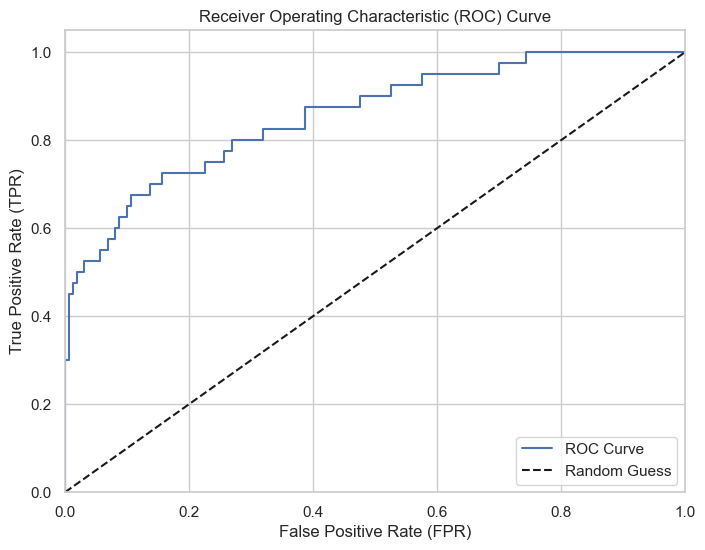

In [20]:
data['predicted_prob'] = model.predict(data)
# Step 1: Calculate ROC curve
fpr, tpr, thresholds = roc_curve(data['STA'], data['predicted_prob'])

# Step 2: Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label='ROC Curve')
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')

# Step 3: Calculate AUC ROC
auc_roc = roc_auc_score(data['STA'], data['predicted_prob'])
print(f'AUC ROC: {auc_roc}')

# Step 4: Show the plot
plt.show()

In [21]:
# Calculate Receiver Operating Characteristic (ROC) curve values.
fpr, tpr, thresholds = roc_curve(data['STA'], data['predicted_prob'])
# Find the optimal threshold index that maximizes the difference between true positive rate (tpr) and false positive rate (fpr).
optimal_idx = np.argmax(tpr - fpr)

# Get the corresponding optimal threshold from the thresholds array.
optimal_threshold = round(thresholds[optimal_idx],3)

# Convert the optimal_threshold to a percentage string before printing
print(f'Best Threshold is : {optimal_threshold}')

Best Threshold is : 0.28


In [25]:
# Calculate predicted classes (usually a threshold of 0.5 is used for binary classification)
data['predicted_class'] = (data['predicted_prob'] > optimal_threshold).astype(int)

# Create the classification report
report = classification_report(data['STA'], data['predicted_class'])

# Print the classification report
print(report)

              precision    recall  f1-score   support

           0       0.91      0.89      0.90       160
           1       0.60      0.65      0.63        40

    accuracy                           0.84       200
   macro avg       0.76      0.77      0.76       200
weighted avg       0.85      0.84      0.85       200

